# 03b – Indicador de Estrutura Hospitalar

**Objetivo:** A partir da base longitudinal, construir um indicador de infraestrutura (qualidade/capacidade) para cada hospital e adiciô-lo como uma nova feature preditiva. O resultado será exportado em um novo arquivo para não sobrescrever a base original.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações gráficas estritas conforme normas da instituição
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 11,
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.5,
    "axes.facecolor": "none",
    "figure.facecolor": "none",
    "axes.grid": False,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False
})

ROOT = Path("..").resolve()
DATA_PATH = ROOT / "data" / "processed" / "base_modelagem.csv"
OUT_PATH = ROOT / "data" / "processed" / "base_modelagem_enriched.csv"
FIG_PATH = ROOT / "reports" / "figures"
FIG_PATH.mkdir(parents=True, exist_ok=True)
def enforce_tcc_style():
    import matplotlib.pyplot as plt
    import seaborn as sns
    try:
        plt.grid(False)
        sns.despine(top=True, right=True, left=False, bottom=False)
        for ax_ in plt.gcf().axes:
            ax_.grid(False)
            ax_.spines['top'].set_visible(False)
            ax_.spines['right'].set_visible(False)
            ax_.spines['bottom'].set_linewidth(1.5)
            ax_.spines['bottom'].set_color('black')
            ax_.spines['left'].set_linewidth(1.5)
            ax_.spines['left'].set_color('black')
            ax_.tick_params(colors='black', width=1.5)
            if ax_.get_title(): ax_.set_title('')
    except Exception: pass


## 1. Carregamento da Base Original

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Registros: {len(df):,}")
print(f"Colunas iniciais: {len(df.columns)}")

Registros: 415,367
Colunas iniciais: 658


## 2. Dicionário de Variáveis do CNES (Disponíveis na Base)
Abaixo, listamos todas as colunas de infraestrutura que foram integradas na `base_modelagem.csv`. Você pode explorar esta tabela para decidir quais farão parte do seu critério clínico de estrutura.

In [3]:
import pandas as pd

# Mapeamento abrangente das instalações (Conforme Estabelecimento.def)
mapa_instalacao = {
    '01': 'Salas de Atendimento Pediatria', '02': 'Salas de Atendimento Feminino', 
    '03': 'Salas de Atendimento Masculino', '04': 'Salas de Atendimento Indiferenciado',
    '05': 'Salas de Repouso/Obs. Pediatria', '06': 'Salas de Repouso/Obs. Feminino',
    '07': 'Salas de Repouso/Obs. Masculino', '08': 'Salas de Repouso/Obs. Indiferenciado',
    '09': 'Consultório Odontológico', '10': 'Sala de Higienização',
    '11': 'Sala de Gesso', '12': 'Sala de Curativo', '13': 'Sala de Pequena Cirurgia',
    '14': 'Consultórios Médicos (Geral)', '15': 'Consultório Clínica Básica',
    '16': 'Consultório Clínica Especializada', '17': 'Consultório Clínica Indiferenciada',
    '18': 'Consultório Não Médico',
    '19': 'Sala Repouso/Obs. Feminino (Urgência)', '20': 'Sala Repouso/Obs. Masculino (Urgência)',
    '21': 'Sala Repouso/Obs. Pediatria (Urgência)', '22': 'Sala Repouso/Obs. Indiferenciado (Urgência)',
    '24': 'Sala Pequenas Cirurgias (Ambulatorial)',
    '30': 'Sala Cirurgia Ambulatorial', '31': 'Sala de Cirurgia (Centro Cirúrgico)', 
    '32': 'Sala de Recuperação Pós-Anestésica',
    '34': 'Sala Pré Parto', '35': 'Sala Parto Normal', '36': 'Sala Curetagem', '37': 'Sala Cirurgia (Outras)'
}

# Tipos de Leito
mapa_leito_tipo = {
    '05': 'Leito Repouso/Obs. Pediatria', '06': 'Leito Repouso/Obs. Feminino',
    '07': 'Leito Repouso/Obs. Masculino', '08': 'Leito Repouso/Obs. Indiferenciado',
    '19': 'Leito Repouso/Obs. Feminino (Urgência)', '20': 'Leito Repouso/Obs. Masculino (Urgência)',
    '21': 'Leito Repouso/Obs. Pediatria (Urgência)', '22': 'Leito Repouso/Obs. Indiferenciado (Urgência)',
    '32': 'Leito Recuperação Pós-Anestésica', '38': 'Leito RN Normal', '39': 'Leito RN Patológico'
}

# Mapeamento de Equipamentos Chave (Conforme Equip_Tp.cnv do DATASUS)
mapa_equip = {
    '1': 'Gama Câmara', '2': 'Mamógrafo', '4': 'Raio X (até 100 mA)', '5': 'Raio X (100 a 500 mA)',
    '6': 'Raio X (> 500mA)', '10': 'Raio X para Hemodinâmica (Essencial IAM)',
    '11': 'Tomógrafo Computadorizado', '12': 'Ressonância Magnética',
    '13': 'Ultrassom Doppler Colorido', '14': 'Ultrassom Ecógrafo', '15': 'Ultrassom Convencional',
    '20': 'Grupo Gerador (Energia)', '21': 'Usina de Oxigênio',
    '39': 'Eletrocardiógrafo', '41': 'Bomba/Balão Intra-Aórtico',
    '42': 'Bomba de Infusão', '46': 'Desfibrilador', '49': 'Marcapasso Temporário',
    '50': 'Monitor de ECG', '51': 'Monitor de Pressão Invasivo', '52': 'Monitor de Pressão Não-Invasivo',
    '54': 'Respirador / Ventilador (Suporte de Vida)', '61': 'Equipamento para Hemodiálise'
}

def classificar_habilitacao(cod):
    grupo = cod[:2] if len(cod) == 4 else (cod[:1] if len(cod) == 3 else cod)
    if grupo in ['09', '90']: return "Transplantes de Órgãos, Tecidos e Células"
    elif grupo == '12': return "Cuidados Prolongados / UTI Neonatal e Pediátrica"
    elif grupo == '14': return "Terapia Renal Substitutiva (Nefrologia / Hemodiálise)"
    elif grupo == '16': return "Alta Complexidade em Oncologia (CACON/UNACON)"
    elif grupo == '17': return "Alta Complexidade em Neurologia / Neurocirurgia"
    elif grupo == '18': return "Traumato-Ortopedia de Média/Alta Complexidade"
    elif grupo == '24': return "Gestação de Alto Risco / Rede Cegonha"
    elif grupo == '25': return "Alta Complexidade ao Paciente Queimado"
    elif grupo == '26': return "Cardiologia / Cirurgia Cardiovascular / Hemodinâmica"
    elif grupo == '30': return "Atenção Especializada na Doença Renal Crônica (DRC)"
    elif grupo == '38': return "Hospitais Especializados em Urgência/Emergência e Trauma"
    else: return "Outras Habilitações (Consulte DATASUS)"

dados_dicionario = []
# Pegamos todas as colunas CNES relevantes
cnes_cols = sorted([c for c in df.columns if any(x in c for x in ['leito', 'equip', 'instalacao', 'possui', 'habilitacao', 'servico'])])

for col in cnes_cols:
    categoria = 'Outros'
    descricao = 'Consultar DATASUS'
    
    if col.startswith('possui_'):
        categoria = 'Binária (Tem/Não Tem)'
        descricao = f"Indica se o hospital possui: {col.replace('possui_', '').replace('_', ' ').title()}"
        
    elif col.startswith('qtd_leitos_'):
        categoria = 'Leitos Totais'
        if 'complementares' in col: descricao = "Leitos de UTI / UCO / UI (Alta Complexidade)"
        elif 'cirurgicos' in col: descricao = "Leitos Cirúrgicos Comuns"
        elif 'clinicos' in col: descricao = "Leitos Clínicos (Enfermaria/Geral)"
            
    elif col.startswith('qtd_leito_tipo_'):
        categoria = 'Tipos de Leito Específicos'
        cod = col.split('_')[-1]
        descricao = mapa_leito_tipo.get(cod, f"Tipo de Leito {cod}")
            
    elif col.startswith('qtd_instalacao_'):
        categoria = 'Instalações Físicas'
        cod = col.split('_')[-1]
        descricao = mapa_instalacao.get(cod, f"Instalação {cod}")
        
    elif col.startswith('habilitacao_'):
        categoria = 'Habilitação SUS'
        cod = col.split('_')[-1]
        descricao = classificar_habilitacao(cod) + f" (Cód {cod})"
        
    elif col.startswith('equip_'):
        categoria = 'Equipamento'
        cod = col.replace('equip_', '')
        descricao = mapa_equip.get(cod, f"Equipamento Genérico (Cód {cod})")
        
    elif col.startswith('servico_apoio_'):
        categoria = 'Serviço de Apoio'
        descricao = col.replace('servico_apoio_', '').replace('_cod', '').replace('_', ' ').title()
        
    elif col.startswith('servico_'):
        categoria = 'Serviço Especializado'
        cod = col.replace('servico_', '')
        # Alguns códigos de serviço especializado clássicos do SUS
        if cod == '114': descricao = "Atenção Cardiovascular (Essencial IAM)"
        elif cod == '104': descricao = "Atenção Oncológica"
        elif cod == '115': descricao = "Atenção em Neurologia/Neurocirurgia"
        elif cod == '116': descricao = "Atenção em Ortopedia e Traumatologia"
        elif cod == '112': descricao = "Serviço de Urgência e Emergência"
        else: descricao = f"Serviço Especializado (Cód {cod})"
            
    dados_dicionario.append({'Coluna na Base': col, 'Categoria': categoria, 'Descrição / Significado': descricao})

df_dic = pd.DataFrame(dados_dicionario)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', None)
display(df_dic.style.set_properties(**{'text-align': 'left'}))


,Coluna na Base,Categoria,Descrição / Significado
0,equip_1,Equipamento,Gama Câmara
1,equip_10,Equipamento,Raio X para Hemodinâmica (Essencial IAM)
2,equip_11,Equipamento,Tomógrafo Computadorizado
3,equip_12,Equipamento,Ressonância Magnética
4,equip_13,Equipamento,Ultrassom Doppler Colorido
5,equip_14,Equipamento,Ultrassom Ecógrafo
6,equip_15,Equipamento,Ultrassom Convencional
7,equip_16,Equipamento,Equipamento Genérico (Cód 16)
8,equip_17,Equipamento,Equipamento Genérico (Cód 17)
9,equip_18,Equipamento,Equipamento Genérico (Cód 18)


In [4]:
#df_dic.to_csv("base.csv", index=False)

## 3. Construção do Indicador de Estrutura Hospitalar
> **PLACEHOLDER:** A regra de negócio para definir se a infraestrutura é "Adequada" ou "Inadequada" será definida aqui. Como exemplo, vamos criar uma variável fictícia para manter o esqueleto.

Escore final — 3 critérios (0 a 3)


 | Critério  | 	Regra	 | Variáveis | 
1. Habilitação cardiológica intervencionista | Possui hemodinâmica/cirurgia cardiovascular/eletrofisiologia	 | habilitacao_2601, 2603, 2604, 2605, 2607–2613, 2696–2698
2. Capacidade de terapia intensiva | Possui leito complementar (UTI/UCO) | 	qtd_leitos_complementares > 0
3. Complexidade máxima (transplante)  | Possui habilitação de transplante cardíaco  | habilitacao_2611

In [5]:
# Lista segura de colunas cardiológicas intervencionistas (excluindo transplante 2611)
cols_cardio = [c for c in df.columns if c.startswith("habilitacao_26") and c != "habilitacao_2611"]

criterio_cardiologia = df[cols_cardio].max(axis=1) > 0
criterio_uti = df["qtd_leitos_complementares"] > 0
criterio_transplante = df.get("habilitacao_2611", pd.Series([0]*len(df))) > 0

df["escore_estrutura"] = (
    criterio_cardiologia.astype(int)
    + criterio_uti.astype(int)
    + criterio_transplante.astype(int)
)

from pandas.api.types import CategoricalDtype
cat_type = CategoricalDtype(categories=["baixa", "média", "alta", "muito alta"], ordered=True)
# Removido: agrupamento de categorias

df["categoria_estrutura"] = df["escore_estrutura"].map({
    0: "baixa", 1: "média", 2: "alta", 3: "muito alta"
}).astype(cat_type)

df["categoria_estrutura_agrupada"] = df["categoria_estrutura"] # Mantendo original temporariamente




print("Escores calculados com sucesso!")


Escores calculados com sucesso!


In [14]:
df = pd.read_csv('/home/carolina/Documents/TCC Documentos/TCC/data/processed/base_modelagem_enriched.csv')

/tmp/ipykernel_2537799/3900953351.py:1: DtypeWarning: Columns (102,108,109,250) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/carolina/Documents/TCC Documentos/TCC/data/processed/base_modelagem_enriched.csv')


In [4]:
df["categoria_estrutura"].value_counts(normalize=True)


categoria_estrutura
alta          0.702136
muito alta    0.191996
média         0.061512
baixa         0.044356
Name: proportion, dtype: float64

In [21]:
df["categoria_estrutura"].unique()

array(['média', 'alta', 'muito alta', 'baixa'], dtype=object)

Com transplante como critério isolado, é bem provável que "muito alta" fique muito rara (poucos hospitais no Brasil fazem transplante cardíaco) — o que é esperado e até bom para a narrativa: mostra que a maior parte da variação relevante está entre "baixa/média/alta", e "muito alta" funciona como categoria de referência de excelência, não como grupo estatisticamente relevante para a interação. Se "muito alta" tiver menos de ~10 hospitais, vale mencionar isso como nota metodológica na hora de interpretar essa categoria (amostra pequena = intervalo de confiança largo).

texto para TCC:

Para investigar a hipótese central deste trabalho — de que o desfecho clínico depende não apenas do risco individual do paciente, mas também da capacidade estrutural do hospital que o atendeu —, foi construído um escore de estrutura hospitalar a partir de três critérios extraídos do CNES, selecionados por sua relevância clínica direta para o manejo do Infarto Agudo do Miocárdio: (i) a presença de habilitação em cardiologia intervencionista, cirurgia cardiovascular ou eletrofisiologia, indicativa da capacidade de realizar procedimentos como angioplastia primária; (ii) a disponibilidade de leitos complementares (Unidade de Terapia Intensiva ou Unidade Coronariana); e (iii) a habilitação para transplante cardíaco, adotada como marcador do nível máximo de complexidade assistencial em cardiologia. Cada critério foi tratado como binário, e a soma dos três originou um escore ordinal de 0 a 3, posteriormente categorizado em quatro níveis de estrutura hospitalar (baixa, média, alta e muito alta).

## 4. Distribuição do Indicador

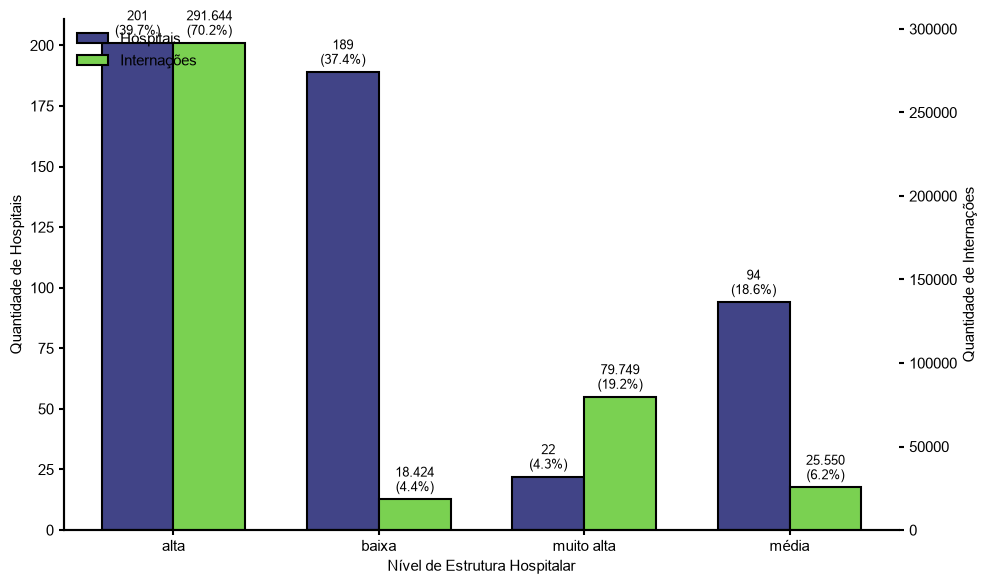

Figura salva: dist_estrutura_hospitalar.jpg


In [15]:
import matplotlib.pyplot as plt
import numpy as np

_vir = plt.cm.viridis

# Mapeamento para nomes mais legíveis (Escores 0, 1, 2, 3)
mapa_nomes = {
    0.0: 'Baixa',
    1.0: 'Média',
    2.0: 'Alta',
    3.0: 'Muito Alta'
}

df_hosp = df.drop_duplicates(subset=["codigo_cnes"])

# Contagens absolutas
cont_hosp = df_hosp["categoria_estrutura"].value_counts().sort_index()
cont_int = df["categoria_estrutura"].value_counts().sort_index()

# Categorias (0, 1, 2, 3) convertidas para os nomes
categorias = [mapa_nomes.get(c, str(c)) for c in cont_hosp.index]

x = np.arange(len(categorias))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Corrigindo para usar cores viridis (primeira e última para contrastar bem)
cor_hosp = _vir(0.2)
cor_int  = _vir(0.8)

# Barras
rects1 = ax.bar(x - width/2, cont_hosp.values, width, label='Hospitais', color=cor_hosp, edgecolor='black', linewidth=1.5)
# Criar um eixo secundário para as internações, já que os números são muito maiores
ax2 = ax.twinx()
rects2 = ax2.bar(x + width/2, cont_int.values, width, label='Internações', color=cor_int, edgecolor='black', linewidth=1.5)

# Labels nos eixos
ax.set_ylabel('Quantidade de Hospitais', color='black', fontsize=11)
ax2.set_ylabel('Quantidade de Internações', color='black', fontsize=11)
ax.set_xlabel('Nível de Estrutura Hospitalar', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(categorias)

# Adicionando os números exatos em cima das barras (Hospitais)
for rect in rects1:
    height = rect.get_height()
    pct = (height / cont_hosp.sum()) * 100
    ax.annotate(f'{int(height):,}\n({pct:.1f}%)'.replace(',', '.'),
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9, color='black')

# Adicionando os números exatos em cima das barras (Internações)
for rect in rects2:
    height = rect.get_height()
    pct = (height / cont_int.sum()) * 100
    ax2.annotate(f'{int(height):,}\n({pct:.1f}%)'.replace(',', '.'),
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9, color='black')

# Legenda unificada
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False)

plt.title('') # Sem título por norma ABNT/TCC
enforce_tcc_style()
ax.grid(False)
ax2.grid(False)

# Remoção manual das bordas superiores e direitas
ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1.5)
ax2.spines['right'].set_color('black')
ax2.spines['right'].set_linewidth(1.5)
ax.tick_params(colors='black', width=1.5)
ax2.tick_params(colors='black', width=1.5)

plt.tight_layout()
plt.savefig(FIG_PATH / "dist_estrutura_hospitalar.jpg", dpi=300, bbox_inches="tight")
plt.show()
print("Figura salva: dist_estrutura_hospitalar.jpg")


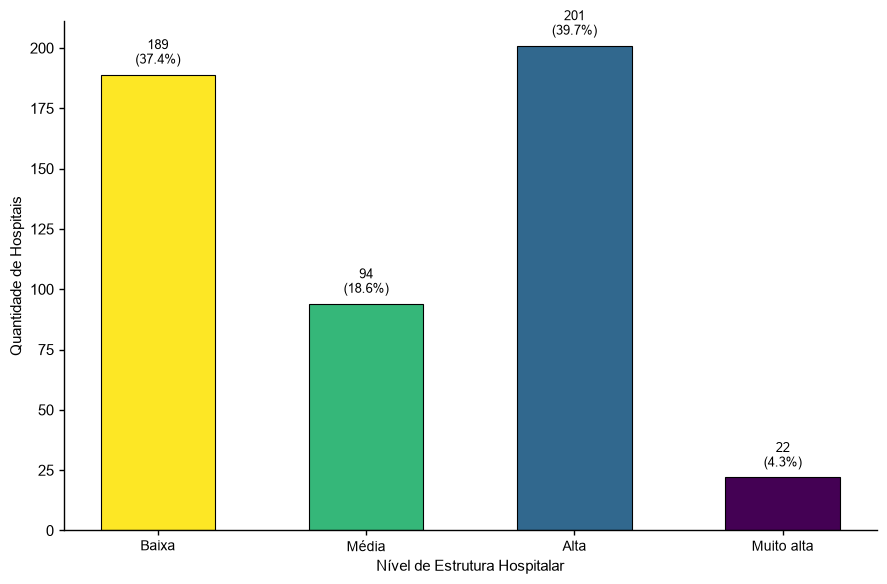

Figura salva: dist_estrutura_hospitalar_hospitais.jpg


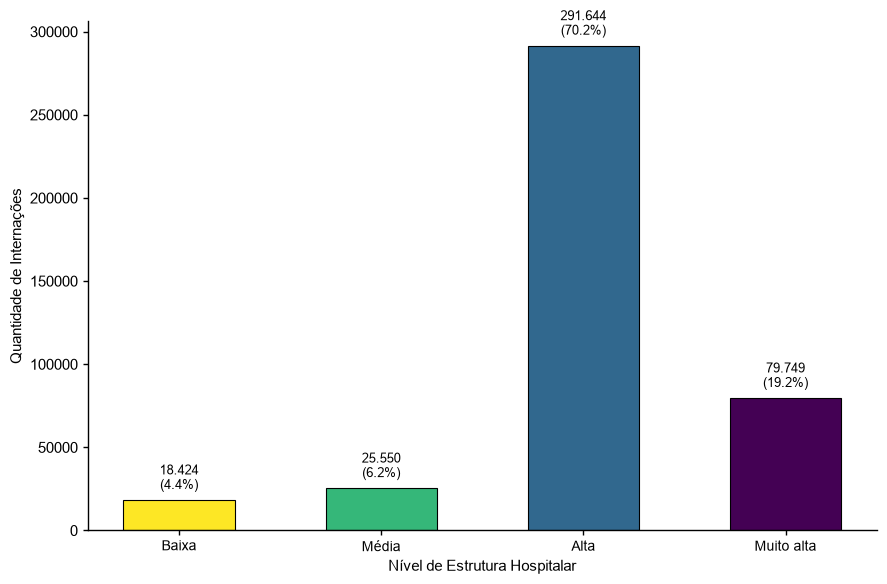

Figura salva: dist_estrutura_hospitalar_internacoes.jpg


In [29]:
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# DADOS
# ============================================================

_vir = plt.cm.viridis

df_hosp = df.drop_duplicates(subset=["codigo_cnes"])

cont_hosp = df_hosp["categoria_estrutura"].value_counts().sort_index()
cont_int = df["categoria_estrutura"].value_counts().sort_index()


# ============================================================
# ORDEM DAS CATEGORIAS
# Baixa → Média → Alta → Muito Alta
# ============================================================

ordem_categorias = [
    "baixa",
    "média",
    "alta",
    "muito alta"
]


# ============================================================
# CORES POR CATEGORIA
# ============================================================

cores_categorias = {
    "baixa": "#fde725",
    "média": "#35b779",
    "alta": "#31688e",
    "muito alta": "#440154"
}


# ============================================================
# ORGANIZAR HOSPITAIS
# ============================================================

dados_hosp = []

for categoria, valor in cont_hosp.items():

    categoria = str(categoria).strip().lower()

    dados_hosp.append(
        (categoria, valor)
    )


dados_hosp = sorted(
    dados_hosp,
    key=lambda x: ordem_categorias.index(x[0])
)


categorias_hosp = [
    categoria.capitalize()
    for categoria, valor in dados_hosp
]

valores_hosp = [
    valor
    for categoria, valor in dados_hosp
]

cores_hosp = [
    cores_categorias[categoria]
    for categoria, valor in dados_hosp
]

x_hosp = np.arange(len(categorias_hosp))


# ============================================================
# ORGANIZAR INTERNAÇÕES
# ============================================================

dados_int = []

for categoria, valor in cont_int.items():

    categoria = str(categoria).strip().lower()

    dados_int.append(
        (categoria, valor)
    )


dados_int = sorted(
    dados_int,
    key=lambda x: ordem_categorias.index(x[0])
)


categorias_int = [
    categoria.capitalize()
    for categoria, valor in dados_int
]

valores_int = [
    valor
    for categoria, valor in dados_int
]

cores_int = [
    cores_categorias[categoria]
    for categoria, valor in dados_int
]

x_int = np.arange(len(categorias_int))


# ============================================================
# 1. GRÁFICO — QUANTIDADE DE HOSPITAIS
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

rects = ax.bar(
    x_hosp,
    valores_hosp,
    width=0.55,
    color=cores_hosp,
    edgecolor="black",
    linewidth=0.8
)


ax.set_ylabel(
    "Quantidade de Hospitais",
    fontsize=11
)

ax.set_xlabel(
    "Nível de Estrutura Hospitalar",
    fontsize=11
)

ax.set_xticks(x_hosp)

ax.set_xticklabels(
    categorias_hosp,
    fontsize=10
)


# ============================================================
# VALORES NAS BARRAS
# ============================================================

total_hosp = sum(valores_hosp)

for rect, valor in zip(rects, valores_hosp):

    pct = (valor / total_hosp) * 100

    ax.annotate(
        f"{int(valor):,}\n({pct:.1f}%)".replace(",", "."),
        xy=(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height()
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9
    )


# ============================================================
# ESTÉTICA
# ============================================================

enforce_tcc_style()

ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")

ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)

ax.tick_params(
    axis="both",
    colors="black",
    width=1.0
)

plt.tight_layout()

plt.savefig(
    FIG_PATH / "dist_estrutura_hospitalar_hospitais.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura salva: dist_estrutura_hospitalar_hospitais.jpg")


# ============================================================
# 2. GRÁFICO — QUANTIDADE DE INTERNAÇÕES
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

rects = ax.bar(
    x_int,
    valores_int,
    width=0.55,
    color=cores_int,
    edgecolor="black",
    linewidth=0.8
)


ax.set_ylabel(
    "Quantidade de Internações",
    fontsize=11
)

ax.set_xlabel(
    "Nível de Estrutura Hospitalar",
    fontsize=11
)

ax.set_xticks(x_int)

ax.set_xticklabels(
    categorias_int,
    fontsize=10
)


# ============================================================
# VALORES NAS BARRAS
# ============================================================

total_int = sum(valores_int)

for rect, valor in zip(rects, valores_int):

    pct = (valor / total_int) * 100

    ax.annotate(
        f"{int(valor):,}\n({pct:.1f}%)".replace(",", "."),
        xy=(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height()
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9
    )


# ============================================================
# ESTÉTICA
# ============================================================

enforce_tcc_style()

ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")

ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)

ax.tick_params(
    axis="both",
    colors="black",
    width=1.0
)

plt.tight_layout()

plt.savefig(
    FIG_PATH / "dist_estrutura_hospitalar_internacoes.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura salva: dist_estrutura_hospitalar_internacoes.jpg")

## 5. Exportação da Nova Base

In [9]:
df.to_csv(OUT_PATH, index=False)
print(f"\u2705 Base enriquecida salva em: {OUT_PATH}")

✅ Base enriquecida salva em: /home/carolina/Documents/TCC Documentos/TCC/data/processed/base_modelagem_enriched.csv
